# Week 1 | Embedding Exploration
### Bass Connections Project: Historical Shifts and Geographical Drifts

In this notebook, we will explore a small embedding model by embedding a few concepts and investigating those embeddings through visualization and dimensionality reduction techniques.

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/bass-connections/ai-cartographers/embedding_explore_activity.ipynb)

#### Install libraries

In [1]:
!pip install sentence-transformers umap-learn scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 858.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

#### Import libraries

In [2]:
# Plotting Basics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Embedding Model & Utils
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Dimensionality Reduction
from sklearn.manifold import TSNE
import umap.umap_ as umap

#### Load Embedding Model from HuggingFace 🤗

##### **Model: all0-MiniLM-L6-v2**
Link:
https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

The model maps sentences & paragraphs to a 384 dimensional dense vector space and

The model is intended to be used as a sentence and short paragraph encoder. Given an input text, it outputs a vector which captures the semantic information. The sentence vector may be used for information retrieval, clustering or sentence similarity tasks.

By default, input text longer than 256 word pieces is truncated.

##### **First, you will need a HuggingFace API token**
Instructions to get your HF_TOKEN:
https://huggingface.co/docs/hub/en/security-tokens

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Define Concepts

Normally, you would be pulling in data. This is for example purposes only. Feel free to modify!

In [4]:
concepts = [
    "quantum computing",
    "machine learning",
    "photosynthesis",
    "democracy",
    "Shakespearean drama",
    "blockchain technology",
    "biodiversity",
    "neural networks",
    "cryptography",
    "global warming"
]

#### Embed Concepts using Embedding Model

**What this does:** uses a pre-trained language model to convert each concept (a text string) into a numerical vector—also called an embedding.

`concepts` is a list of strings (e.g., words or phrases)

`model.encode()` passes each concept through the language model

The output, `embeddings`, is a matrix where each row is a high-dimensional vector representing the meaning of a concept

In [5]:
embeddings = model.encode(concepts)

#### t-SNE Plot

t-SNE is a non-linear dimensionality reduction technique primarily used for visualizing high-dimensional data in 2 or 3 dimensions.

**It works by:**

Measuring pairwise similarities between data points in high-dimensional space.

Mapping those points to a low-dimensional space such that similar points stay close together, while dissimilar points are modeled far apart.

**This makes it especially useful for:**

Exploring the structure of embeddings (e.g., word, concept, image embeddings),

Identifying clusters or local groupings in data.

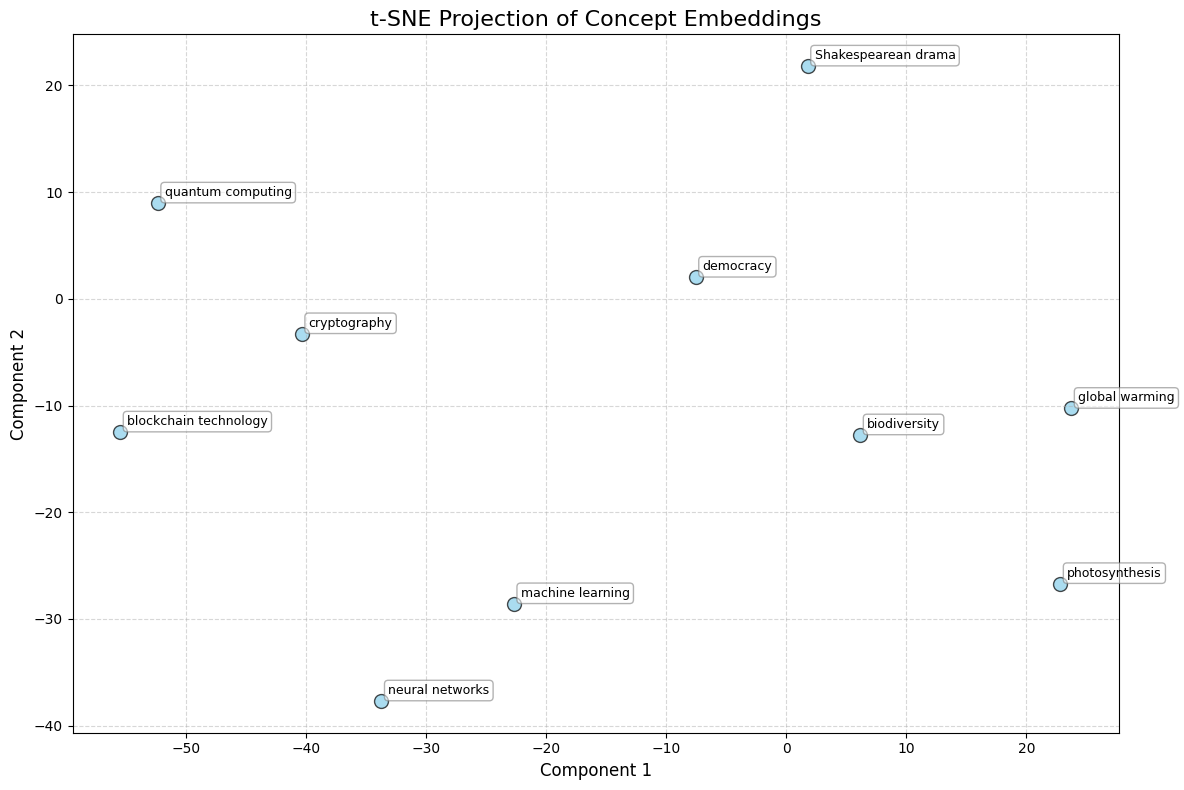

In [6]:
# t-SNE projection
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=100, alpha=0.7, edgecolors='k', c='skyblue')

# Annotate points
for i, concept in enumerate(concepts):
    plt.annotate(concept,
                 (tsne_result[i, 0], tsne_result[i, 1]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='white', alpha=0.6))


plt.title("t-SNE Projection of Concept Embeddings", fontsize=16)
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### UMAP Plot

UMAP is a powerful non-linear dimensionality reduction technique that preserves both local and global structure in high-dimensional data. Compared to t-SNE, UMAP is often:

Faster to compute,

Better at preserving global relationships,

More stable across different runs.

**It works by:**

Constructing a graph to capture the topological structure of the data manifold,

Optimizing a low-dimensional layout that maintains this structure as faithfully as possible.

**Use cases include:**

Visualizing embeddings (e.g., concepts, documents, biological data),

Discovering clusters and groupings in complex datasets.


*UMAP has tunable parameters like n_neighbors (controls local vs global focus) and min_dist (controls how tightly points can cluster), which allow flexibility in visualization.*

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


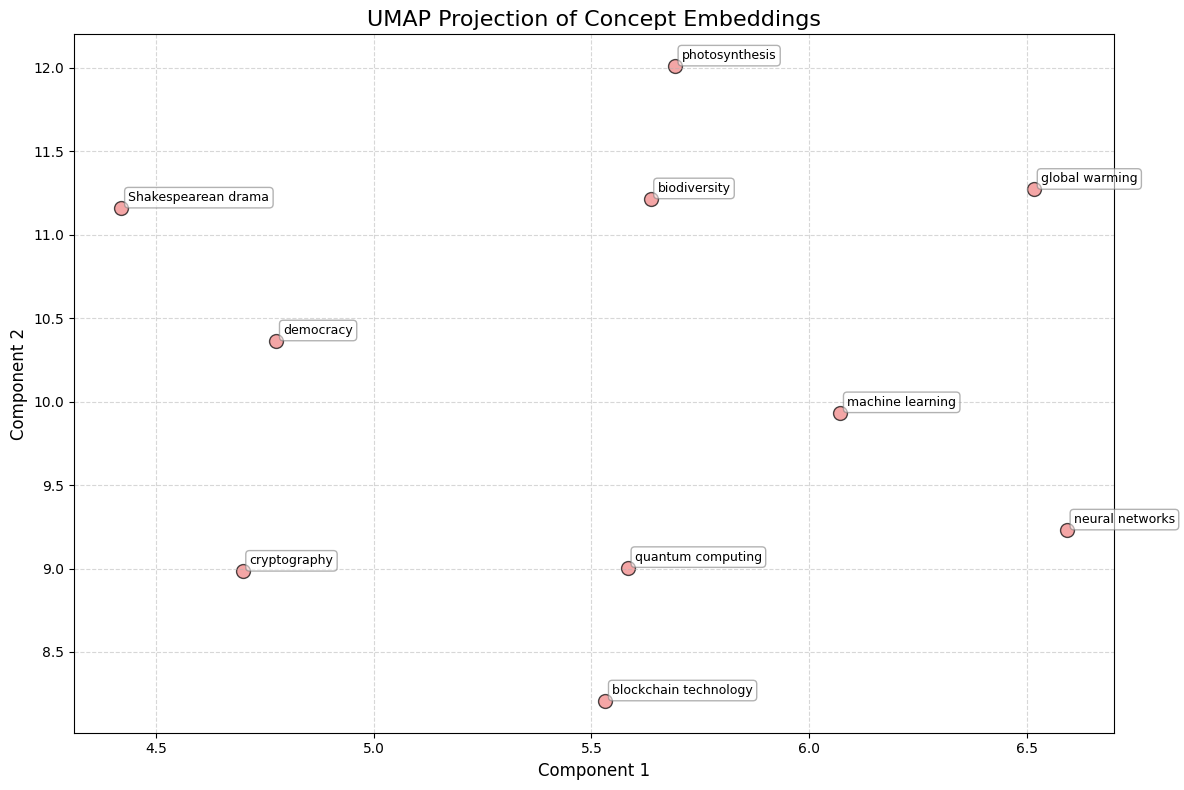

In [7]:
# UMAP projection
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
umap_result = reducer.fit_transform(embeddings)

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], s=100, alpha=0.7, edgecolors='k', c='lightcoral')

# Annotate points
for i, concept in enumerate(concepts):
    plt.annotate(concept,
                 (umap_result[i, 0], umap_result[i, 1]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='white', alpha=0.6))


plt.title("UMAP Projection of Concept Embeddings", fontsize=16)
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Heatmap of Cosine Similarity

**Cosine similarity** is a measure of similarity between two non-zero vectors based on the angle between them, rather than their magnitude. It’s especially useful in high-dimensional spaces (like embeddings) where the direction of the vector matters more than its length.

Ranges from `-1` (opposite direction) to `1` (same direction),

A value of `1` means the vectors are identical in direction,

A value of `0` means they are orthogonal (no similarity),

Commonly used for comparing text embeddings, concept vectors, or document similarity.

Because cosine similarity ignores magnitude, it's particularly well-suited to comparing normalized feature vectors where relative orientation is more informative than scale.

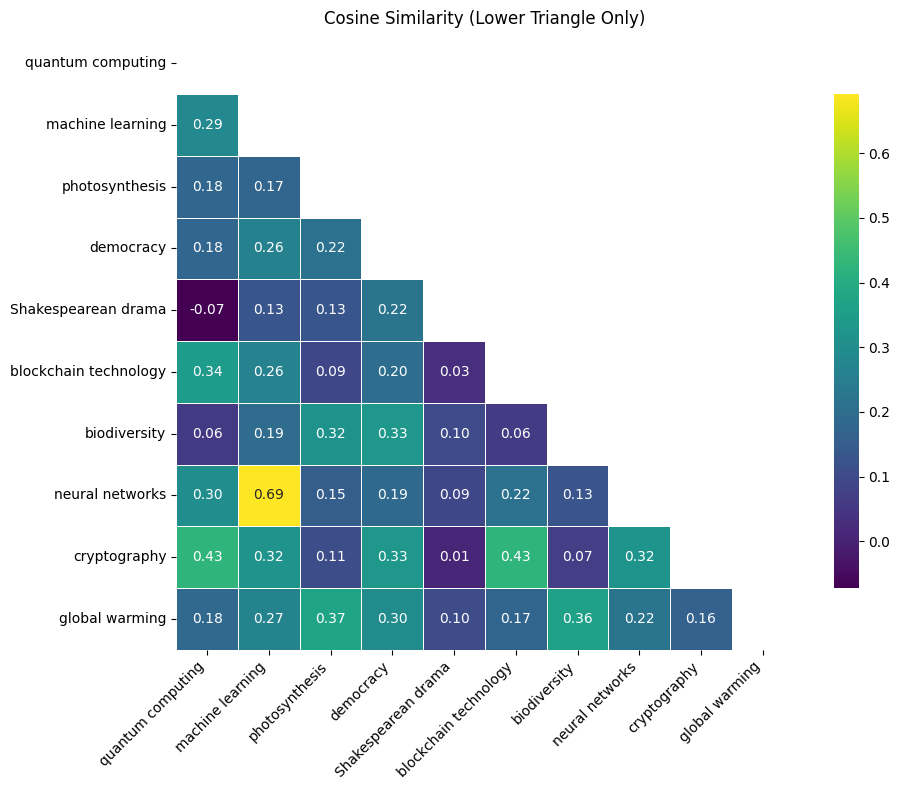

In [8]:
# Compute cosine similarity matrix
cos_sim_matrix = cosine_similarity(embeddings)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(cos_sim_matrix, dtype=bool))

# Plot heatmap with mask
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim_matrix, mask=mask, xticklabels=concepts, yticklabels=concepts,
            cmap='viridis', annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Cosine Similarity (Lower Triangle Only)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



#### Graph Network Plot

A graph network plot is a visual representation of concepts (or nodes) and the similarities between them (edges). In this context:

Nodes represent individual concepts or items.

Edges connect nodes whose cosine similarity exceeds a chosen threshold.

Edge weights reflect the degree of similarity (stronger = more similar).

Node positions are computed using a force-directed layout, which spaces nodes based on connection strength.

**This plot helps:**

Reveal clusters of closely related concepts,

Highlight hubs or central concepts in the similarity network,

Make high-dimensional similarity data more interpretable.

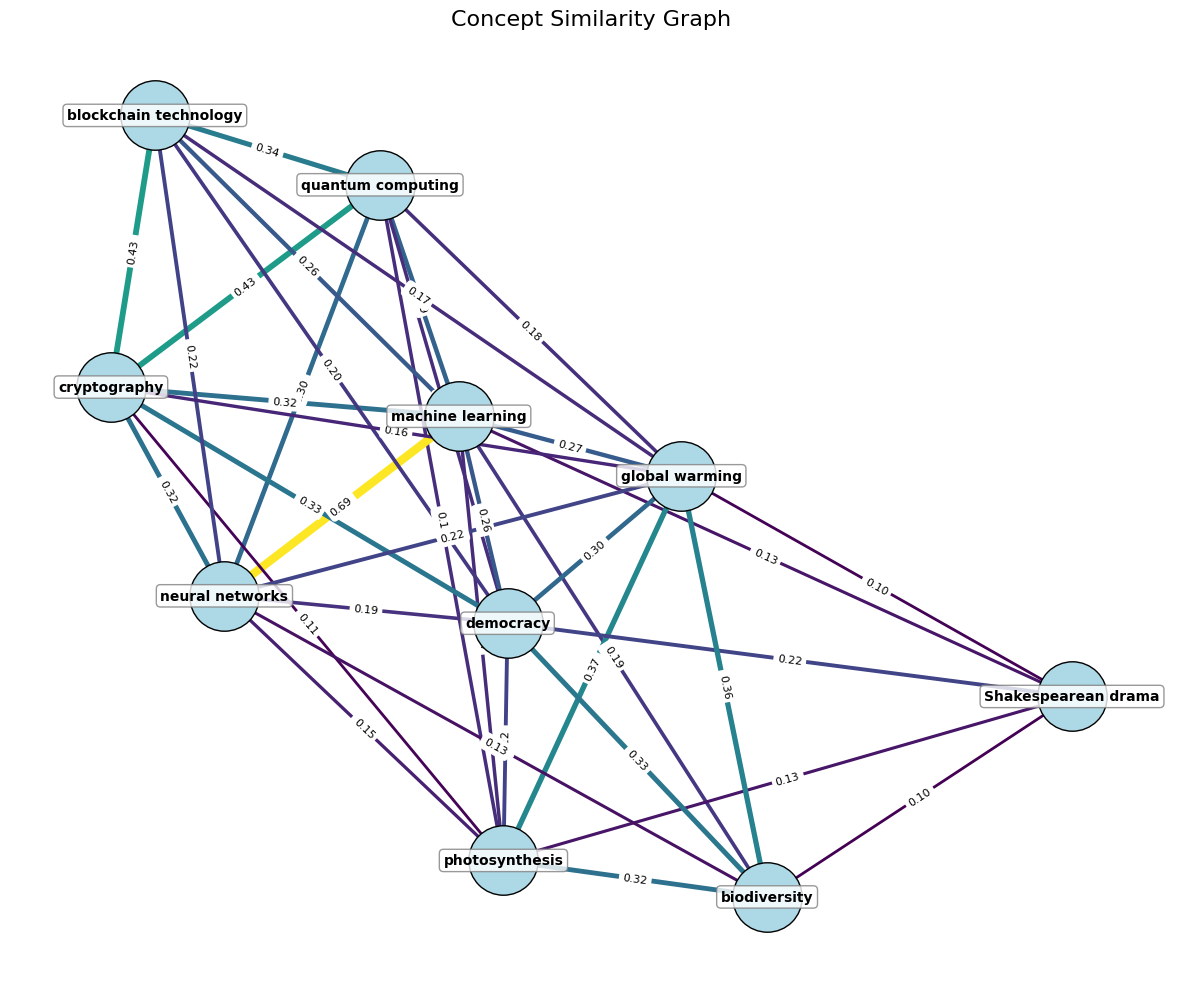

In [9]:
# Create graph
G = nx.Graph()

# Add nodes
for concept in concepts:
    G.add_node(concept)

# Add edges with similarity above a threshold
threshold = 0.1
for i in range(len(concepts)):
    for j in range(i + 1, len(concepts)):
        sim = cos_sim_matrix[i, j]
        if sim > threshold:
            G.add_edge(concepts[i], concepts[j], weight=sim)

# Layout
pos = nx.spring_layout(G, seed=42, k=0.5)
edges = G.edges(data=True)
weights = [edge[2]['weight'] for edge in edges]
norm_weights = [(w - min(weights)) / (max(weights) - min(weights) + 1e-5) for w in weights]
widths = [2 + 4 * w for w in norm_weights]

# Draw nodes and edges
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2500, edgecolors='black', linewidths=1)
nx.draw_networkx_edges(G, pos, edge_color=weights, edge_cmap=plt.cm.viridis, width=widths)

# Annotate each node with background
for node, (x, y) in pos.items():
    plt.text(x, y,
             node,
             fontsize=10,
             fontweight='bold',
             ha='center',
             va='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

# Draw edge labels
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Concept Similarity Graph", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()